In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score

In [10]:
df = pd.read_csv("Diabetes_prediction.csv")

df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Diagnosis
0,2,115.863387,56.410731,24.336736,94.385783,26.455940,0.272682,20.100494,0
1,2,92.490122,70.615520,23.443591,138.652426,23.910167,0.665160,44.912281,0
2,1,88.141469,63.262618,23.404364,149.358082,21.948250,0.676022,48.247873,1
3,2,108.453101,67.793632,20.751580,108.751638,24.209304,0.289636,42.749868,0
4,1,127.849443,94.725685,22.603078,25.269987,32.997477,0.601315,32.797789,0


In [11]:
print(df.info())

print("\nShape of Dataset:")
print(df.shape)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nTotal Missing Values:")
print(df.isnull().sum().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               1000 non-null   int64  
 1   Glucose                   1000 non-null   float64
 2   BloodPressure             1000 non-null   float64
 3   SkinThickness             1000 non-null   float64
 4   Insulin                   1000 non-null   float64
 5   BMI                       1000 non-null   float64
 6   DiabetesPedigreeFunction  1000 non-null   float64
 7   Age                       1000 non-null   float64
 8   Diagnosis                 1000 non-null   int64  
dtypes: float64(7), int64(2)
memory usage: 70.4 KB
None

Shape of Dataset:
(1000, 9)

Missing Values:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFun

In [12]:
df = df.drop_duplicates()

print("New Shape:", df.shape)

New Shape: (1000, 9)


In [14]:
X = df[['Pregnancies',
        'Glucose',
        'BloodPressure',
        'SkinThickness',
        'Insulin',
        'BMI',
        'DiabetesPedigreeFunction',
        'Age']]

y = df['Diagnosis']
print(X.head())

   Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
0            2  115.863387      56.410731      24.336736   94.385783   
1            2   92.490122      70.615520      23.443591  138.652426   
2            1   88.141469      63.262618      23.404364  149.358082   
3            2  108.453101      67.793632      20.751580  108.751638   
4            1  127.849443      94.725685      22.603078   25.269987   

         BMI  DiabetesPedigreeFunction        Age  
0  26.455940                  0.272682  20.100494  
1  23.910167                  0.665160  44.912281  
2  21.948250                  0.676022  48.247873  
3  24.209304                  0.289636  42.749868  
4  32.997477                  0.601315  32.797789  


In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(750, 8)
(250, 8)


In [ ]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)
print(X_train[:5])

[[-0.5751838   0.95359069 -0.10888034 -0.81401363 -0.92328936 -0.13363778
  -0.43633231  0.85105955]
 [ 0.17767458 -0.99537599  0.86333468  0.89211748  0.26439551 -0.58892364
  -0.43926224  0.0547428 ]
 [-0.5751838  -1.46198912 -0.50400418  1.02955597  0.92416466 -2.40163283
   0.67324322 -0.32503963]
 [ 1.68339134 -0.11968525  0.67372801 -1.06920192 -0.81213195 -1.18816409
   1.76349994  0.01792668]
 [ 2.43624973 -1.97325344  0.49178091 -1.5419947  -0.49591732  0.32923579
  -1.63476691  1.11276772]]


In [19]:
model = LogisticRegression(max_iter=1000, random_state=42)

model.fit(X_train, y_train)

print("Model Trained Successfully")
print("Training Accuracy:", model.score(X_train, y_train))

Model Trained Successfully
Training Accuracy: 0.6933333333333334


In [20]:
y_pred = model.predict(X_test)

print("Actual Values")
print(y_test.values)

print("\nPredicted Values")
print(y_pred)

Actual Values
[0 0 0 0 0 0 1 0 1 0 0 0 1 0 0 1 0 0 1 0 1 0 0 0 1 1 0 1 1 0 1 0 0 0 1 0 0
 0 0 0 0 0 0 0 0 0 0 0 1 1 0 1 0 1 0 1 0 0 0 1 0 0 0 0 0 1 0 0 0 0 0 0 1 1
 1 0 0 0 0 1 0 0 1 0 1 1 0 0 0 1 0 1 1 0 1 0 0 0 1 0 0 0 1 1 0 1 0 0 0 1 0
 0 0 1 0 0 0 0 0 0 1 1 0 1 0 0 0 0 0 0 0 0 1 0 1 0 0 1 1 0 0 1 0 1 0 0 0 0
 0 1 0 0 0 1 0 0 0 1 1 0 0 1 0 0 0 1 0 0 0 1 0 0 0 0 0 1 0 0 0 1 1 0 1 1 0
 0 0 1 1 0 1 0 1 0 0 0 0 1 1 0 1 0 0 1 0 0 1 0 1 0 0 0 0 0 1 0 0 0 1 0 1 0
 0 0 0 1 0 1 1 0 0 1 0 1 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0]

Predicted Values
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0

In [4]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy :", accuracy)
print(classification_report(y_test, y_pred))

NameError: name 'accuracy_score' is not defined

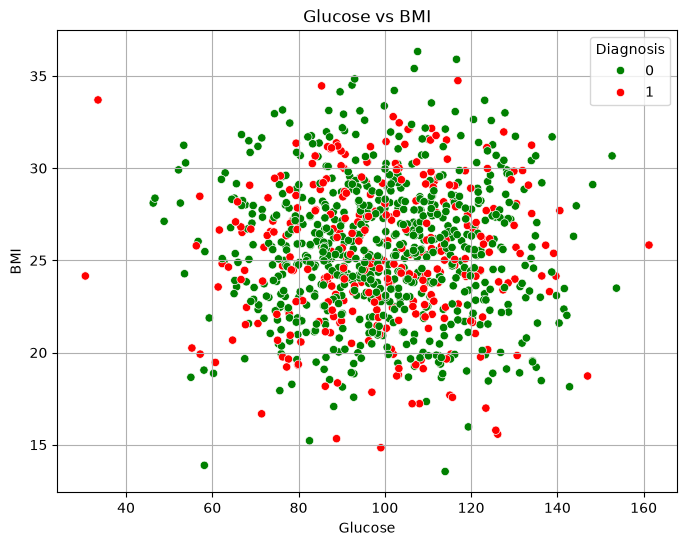

In [32]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="Glucose",
    y="BMI",
    hue="Diagnosis",
    palette=["green", "red"]
)

plt.title("Glucose vs BMI")
plt.xlabel("Glucose")
plt.ylabel("BMI")

plt.grid(True)

plt.show()

In [24]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[174   0]
 [ 75   1]]


In [25]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.70      1.00      0.82       174
           1       1.00      0.01      0.03        76

    accuracy                           0.70       250
   macro avg       0.85      0.51      0.42       250
weighted avg       0.79      0.70      0.58       250



In [26]:
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Precision :", precision)
print("Recall :", recall)
print("F1 Score :", f1)

Precision : 1.0
Recall : 0.013157894736842105
F1 Score : 0.025974025974025976


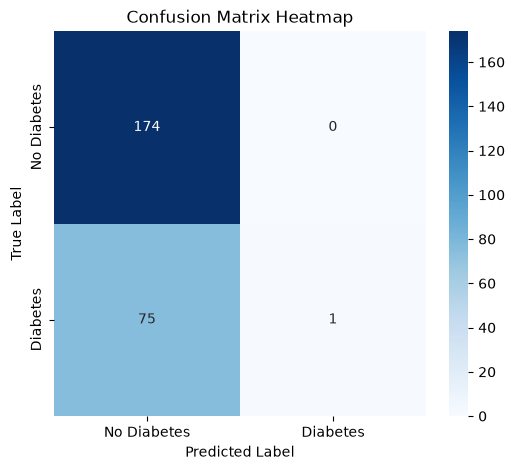

In [27]:
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['No Diabetes','Diabetes'],
    yticklabels=['No Diabetes','Diabetes']
)

plt.title("Confusion Matrix Heatmap")

plt.xlabel("Predicted Label")

plt.ylabel("True Label")

plt.show()

In [ ]:
#roc curve and AUC score
y_prob = model.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

auc_score = roc_auc_score(y_test, y_prob)

print("AUC Score:", auc_score)

AUC Score: 0.48495160314579555


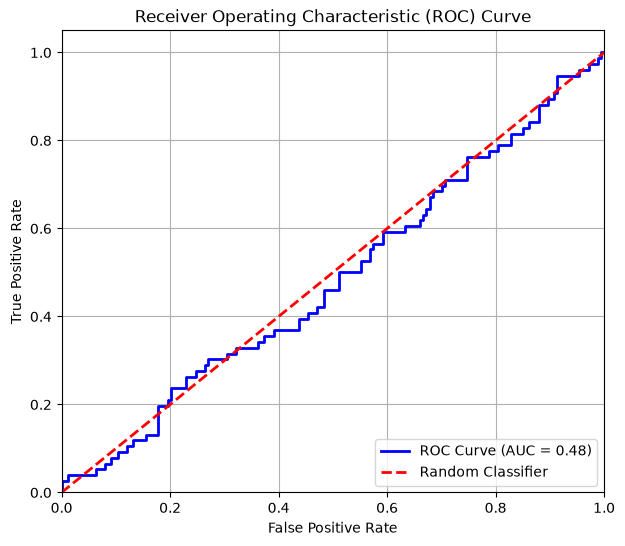

In [31]:
# Predict probabilities
y_prob = model.predict_proba(X_test)[:, 1]

# ROC values
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# AUC
auc_score = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(7,6))

plt.plot(fpr, tpr,
         color="blue",
         linewidth=2,
         label=f"ROC Curve (AUC = {auc_score:.2f})")

plt.plot([0,1], [0,1],
         linestyle="--",
         color="red",
         linewidth=2,
         label="Random Classifier")

plt.xlim([0,1])
plt.ylim([0,1.05])

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic (ROC) Curve")

plt.legend(loc="lower right")
plt.grid(True)

plt.show()